# PR10 · Realign frames and identify what movement correction cannot repair

<!-- paper-first -->
### Research question

**Reading:** [PP02](../../curriculum/papers/processing.md#pp02). Review the assigned figure or result before starting the lesson.

**Question:** Why can aligned frames still contain motion-related differences in connectivity?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Distinguish displacement estimates from intensity artifacts.
- Calculate a stated framewise-displacement convention with units.
- Explain why a corrected mean image cannot certify a time series.

## Understand the operation

Rigid-body motion correction estimates head pose for each volume relative to a reference and resamples volumes into a common geometry. The estimated six parameters describe a model of position and rotation, not every effect of movement on MRI. Through-plane motion, spin-history effects, susceptibility changes and within-volume movement can alter intensities in ways that rigid resampling does not reverse.

Framewise displacement summarizes changes in estimated pose between consecutive frames. One common convention sums absolute translation changes and rotation changes converted to arc length using a chosen head radius. Rotations must be in radians for that conversion. Other FD conventions differ, so record the implementation and radius instead of treating every column named FD as interchangeable. The first derivative-based value is undefined without a prior frame; a displayed zero is a convention, not a measured absence of movement.

Our toy creates integer image translations that are known exactly. Applying their inverses recovers the geometry, but an imposed intensity loss remains. Because we know the motions, this is transform application, not a motion-estimation benchmark. We then calculate a one-dimensional subset of FD and deliberately feed degrees into the radian formula. The numerical result is wildly different although the code runs. Real QC needs pose traces, image movies, outlier measures and relationships with the task; six nuisance regressors or a small mean FD cannot establish that the biological effect is uncontaminated.

## Transformation contract

**Input:** frames, reference geometry, and pose transforms. **Output:** resampled frames plus pose/FD records. **Preserved under exact toy correction:** sampled object location. **Not recovered:** imposed intensity dropout. **Changed:** interpolation and noise structure for noninteger real movements.


## Read the actual course material

- [DartBrains: Preprocessing, Image Transformations and Cost Functions](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Preprocessing.py). CC BY-SA 4.0; linked pinned course chapter.
- [fMRIPrep: pipeline details](https://fmriprep.org/en/stable/workflows.html). Official project documentation; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Apply the known inverse translations and compare geometry with intensity preservation. Compute this stated FD convention using rotations in radians. Label the first frame undefined and explain why FD is not a direct measurement of neuronal contamination. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


corrected intensity errors: [0.         0.         0.06799391 0.         0.        ]


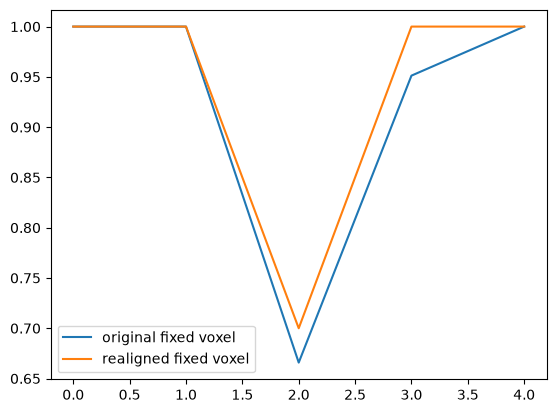

In [1]:
import numpy as np
from scipy.ndimage import shift
import matplotlib.pyplot as plt
r,c=np.mgrid[:50,:50]; reference=np.exp(-((r-25)**2+(c-25)**2)/80)
translations=np.array([0,0,2,2,0])
frames=np.stack([shift(reference,(0,float(d)),order=1) for d in translations])
frames[2]*=.7
aligned=np.stack([shift(frame,(0,-float(d)),order=1)
                  for frame,d in zip(frames,translations)])
inside=(r>8)&(r<42)&(c>8)&(c<42)
errors=np.array([np.mean(abs(frame[inside]-reference[inside])) for frame in aligned])
print('corrected intensity errors:',errors)
assert errors[0]<1e-12 and errors[2]>.03
plt.plot(frames[:,25,25],label='original fixed voxel')
plt.plot(aligned[:,25,25],label='realigned fixed voxel'); plt.legend(); plt.show()


In [2]:
rotation_deg=np.array([0.,0.,1.,1.,0.])
rotation_rad=np.deg2rad(rotation_deg)
fd=np.r_[np.nan,np.abs(np.diff(translations))+50*np.abs(np.diff(rotation_rad))]
bad_fd=np.r_[np.nan,np.abs(np.diff(translations))+50*np.abs(np.diff(rotation_deg))]
print('FD(mm), correct vs degrees-as-radians:',fd,bad_fd)
assert np.isclose(fd[2],2+50*np.pi/180) and bad_fd[2]==52
print('Radius convention:50mm; rotations:radians; first value:undefined.')


FD(mm), correct vs degrees-as-radians: [       nan 0.         2.87266463 0.         2.87266463] [nan  0. 52.  0. 52.]
Radius convention:50mm; rotations:radians; first value:undefined.


## Check and explain

Unaffected integer-shift frames align exactly in the inspected interior. The frame with30% intensity loss remains wrong. Correct FD at the movement is about2.873mm; the unit-error branch reports52mm. Explain both failures in separate sentences.

## Deliberately wrong method

Calling resampled data motion-free ignores the persistent intensity change. Converting degree values as though radians also makes a severe unit error. Neither should be hidden by normalizing the trace until it looks familiar.

## Transfer to an actual dataset or tool — guided assignment

In DartBrains Preprocessing, compare realignment and alignment-report sections. For a real preprocessed run, inspect volume motion, six parameter traces and FD units; mark frames near task events and inspect the movie. Record the reference image and interpolation count. If interpreting a group difference, check whether motion differs with the outcome. Use validated estimation software; our exact known translations are a teaching construction.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why can residual artifacts remain after alignment? **Answer:** movement changes signal generation as well as geometry.
2. Why report an FD convention? **Answer:** radius, rotation units and aggregation differ; a threshold cannot be interpreted without them.


### Return to the research question

Revisit [PP02](../../curriculum/papers/processing.md#pp02) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
